In [2]:
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Visual settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
# Download QQQ (Nasdaq 100 ETF) - 5min bars, last 60 days
# QQQ is used as a proxy for NQ futures (Nasdaq 100)
ticker = 'QQQ'
data = yf.download(ticker, period='60d', interval='5m', auto_adjust=True)

# Clean up multi-index columns if present
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

print(f"Ticker: {ticker}")
print(f"Total bars: {len(data)}")
print(f"Date range: {data.index[0]} to {data.index[-1]}")
print(f"\nFirst rows:")
data.head()

[*********************100%***********************]  1 of 1 completed

Ticker: QQQ
Total bars: 4680
Date range: 2026-03-03 14:30:00+00:00 to 2026-05-27 19:55:00+00:00

First rows:


Price,Close,High,Low,Open,Volume
Datetime,,,,,
2026-03-03 14:30:00+00:00,596.169983,598.559998,595.859985,596.320007,7684019
2026-03-03 14:35:00+00:00,597.750000,599.390015,595.590027,596.200012,2641270
2026-03-03 14:40:00+00:00,596.239990,598.179993,595.859985,597.750000,1934066
2026-03-03 14:45:00+00:00,595.539978,598.182495,595.309998,596.239990,2239296
2026-03-03 14:50:00+00:00,596.575012,597.059998,595.239990,595.539978,1514924


Data summary:
Price        Close         High          Low         Open        Volume
count  4680.000000  4680.000000  4680.000000  4680.000000  4.680000e+03
mean    639.442553   639.888901   638.961822   639.425848  7.493555e+05
std      50.020687    49.997343    50.017531    50.009905  1.691173e+06
min     555.760010   556.179993   555.599976   555.760010  0.000000e+00
25%     598.592484   599.150024   598.265015   598.607483  2.773058e+05
50%     628.444977   629.059998   628.089996   628.235046  4.619455e+05
75%     684.030014   684.330032   683.457504   683.934387  7.470025e+05
max     731.869995   733.320007   731.159973   732.950012  3.269962e+07

Column types:
Price
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
dtype: object

Any missing values?
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64


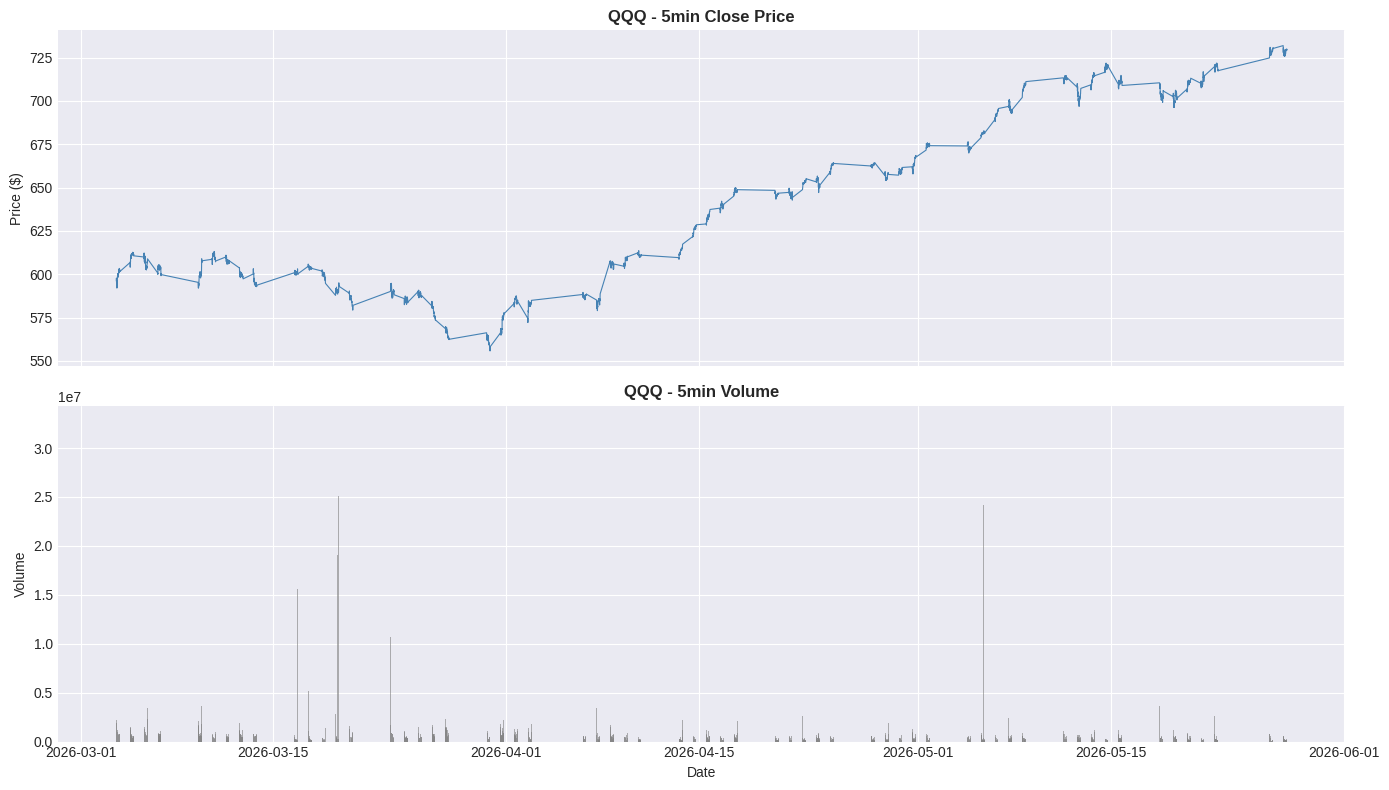

In [4]:
# Basic statistics of the data
print("Data summary:")
print(data.describe())

print("\nColumn types:")
print(data.dtypes)

print("\nAny missing values?")
print(data.isnull().sum())

# Visualize price and volume
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(data.index, data['Close'], linewidth=0.8, color='steelblue')
ax1.set_title(f'{ticker} - 5min Close Price', fontweight='bold')
ax1.set_ylabel('Price ($)')

ax2.bar(data.index, data['Volume'], width=0.009, color='gray', alpha=0.6)
ax2.set_title(f'{ticker} - 5min Volume', fontweight='bold')
ax2.set_ylabel('Volume')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.show()

In [5]:
def calculate_volume_profile(df, num_bins=50, value_area_pct=0.70):
    """
    Calculate Volume Profile for a given price/volume dataset.

    Parameters:
    - df: DataFrame with 'High', 'Low', 'Close', 'Volume' columns
    - num_bins: number of price bins (default 50)
    - value_area_pct: percentage of volume in Value Area (default 70%)

    Returns:
    - profile: DataFrame with price bins and accumulated volume
    - poc: Point of Control price
    - vah: Value Area High
    - val: Value Area Low
    """
    # Define price range
    price_min = df['Low'].min()
    price_max = df['High'].max()

    # Create price bins
    bins = np.linspace(price_min, price_max, num_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2

    # Accumulate volume per bin
    # For each bar, distribute its volume across the price range it covered
    volume_per_bin = np.zeros(num_bins)

    for idx, row in df.iterrows():
        bar_low = row['Low']
        bar_high = row['High']
        bar_volume = row['Volume']

        # Find which bins this bar touches
        bins_touched = (bins[:-1] <= bar_high) & (bins[1:] >= bar_low)
        n_bins_touched = bins_touched.sum()

        if n_bins_touched > 0:
            # Distribute volume equally across touched bins
            volume_per_bin[bins_touched] += bar_volume / n_bins_touched

    # Create profile DataFrame
    profile = pd.DataFrame({
        'price': bin_centers,
        'volume': volume_per_bin
    })

    # Find POC (price level with max volume)
    poc_idx = profile['volume'].idxmax()
    poc = profile.loc[poc_idx, 'price']

    # Calculate Value Area (70% of volume around POC)
    total_volume = profile['volume'].sum()
    target_volume = total_volume * value_area_pct

    # Expand from POC outward until we capture target_volume
    va_volume = profile.loc[poc_idx, 'volume']
    va_high_idx = poc_idx
    va_low_idx = poc_idx

    while va_volume < target_volume:
        # Check what's above and below current VA
        vol_above = profile.loc[va_high_idx + 1, 'volume'] if va_high_idx + 1 < len(profile) else 0
        vol_below = profile.loc[va_low_idx - 1, 'volume'] if va_low_idx - 1 >= 0 else 0

        if vol_above == 0 and vol_below == 0:
            break

        # Expand toward higher volume side
        if vol_above >= vol_below:
            va_high_idx += 1
            va_volume += vol_above
        else:
            va_low_idx -= 1
            va_volume += vol_below

    vah = profile.loc[va_high_idx, 'price']
    val = profile.loc[va_low_idx, 'price']

    return profile, poc, vah, val


# Test the function with all data
profile, poc, vah, val = calculate_volume_profile(data)

print(f"Volume Profile for {ticker} (last 60 days)")
print(f"POC (Point of Control): ${poc:.2f}")
print(f"VAH (Value Area High):  ${vah:.2f}")
print(f"VAL (Value Area Low):   ${val:.2f}")
print(f"Value Area Width:       ${vah-val:.2f} ({(vah-val)/poc*100:.1f}% of POC)")

Volume Profile for QQQ (last 60 days)
POC (Point of Control): $600.03
VAH (Value Area High):  $660.45
VAL (Value Area Low):   $557.38
Value Area Width:       $103.08 (17.2% of POC)


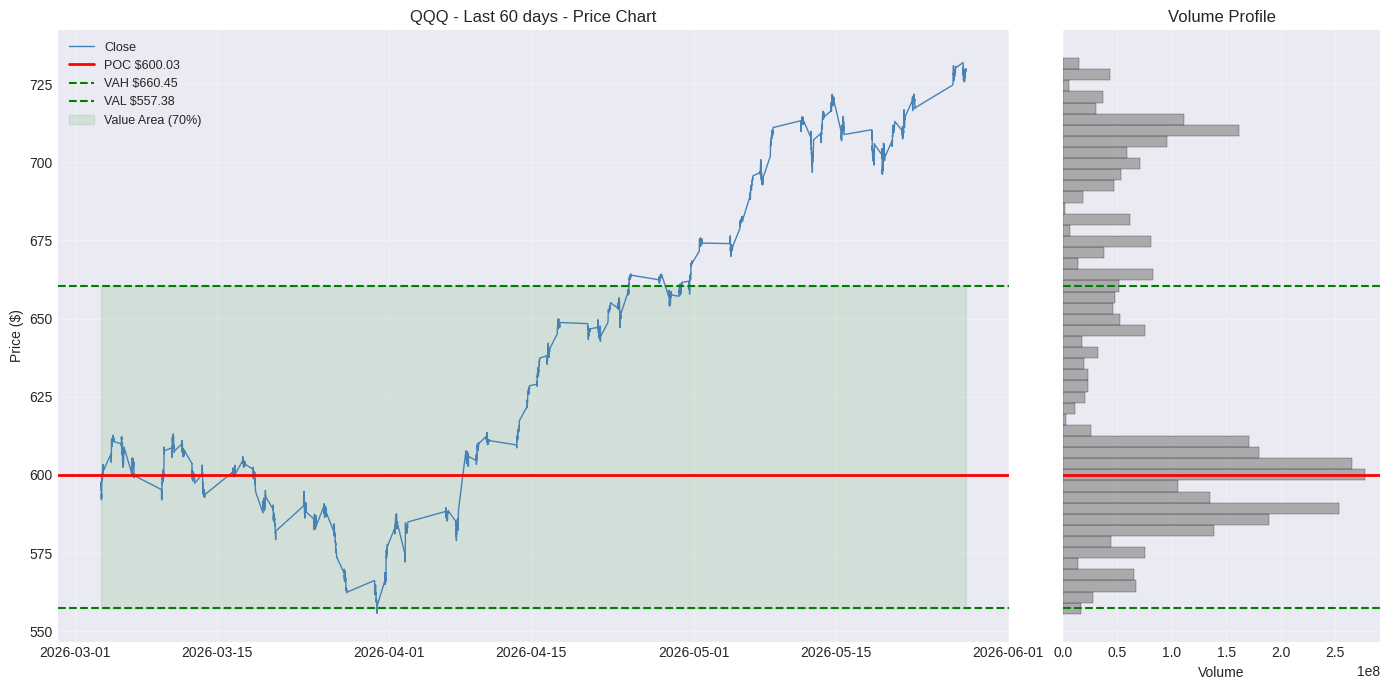

In [6]:
def plot_volume_profile(df, profile, poc, vah, val, title="Volume Profile"):
    """Plot price chart with Volume Profile on the side."""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7),
                                     gridspec_kw={'width_ratios': [3, 1]},
                                     sharey=True)

    # Left: price chart
    ax1.plot(df.index, df['Close'], linewidth=1, color='steelblue', label='Close')
    ax1.axhline(poc, color='red', linestyle='-', linewidth=2, label=f'POC ${poc:.2f}')
    ax1.axhline(vah, color='green', linestyle='--', linewidth=1.5, label=f'VAH ${vah:.2f}')
    ax1.axhline(val, color='green', linestyle='--', linewidth=1.5, label=f'VAL ${val:.2f}')
    ax1.fill_between(df.index, val, vah, alpha=0.1, color='green', label='Value Area (70%)')
    ax1.set_title(f'{title} - Price Chart')
    ax1.set_ylabel('Price ($)')
    ax1.legend(loc='upper left', fontsize=9)
    ax1.grid(True, alpha=0.3)

    # Right: horizontal volume profile
    ax2.barh(profile['price'], profile['volume'], height=(profile['price'].iloc[1]-profile['price'].iloc[0]),
              color='gray', alpha=0.6, edgecolor='black', linewidth=0.3)
    ax2.axhline(poc, color='red', linestyle='-', linewidth=2)
    ax2.axhline(vah, color='green', linestyle='--', linewidth=1.5)
    ax2.axhline(val, color='green', linestyle='--', linewidth=1.5)
    ax2.set_title('Volume Profile')
    ax2.set_xlabel('Volume')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# Plot the volume profile for the full 60 days
plot_volume_profile(data, profile, poc, vah, val, title=f"{ticker} - Last 60 days")

In [7]:
def get_daily_profiles(df, num_bins=30):
    """Calculate a Volume Profile for each trading day."""

    # Add date column (no time)
    df_copy = df.copy()
    df_copy['date'] = df_copy.index.date

    daily_profiles = {}

    for date, day_data in df_copy.groupby('date'):
        if len(day_data) < 20:  # Skip days with too few bars
            continue

        profile, poc, vah, val = calculate_volume_profile(day_data, num_bins=num_bins)

        daily_profiles[date] = {
            'profile': profile,
            'poc': poc,
            'vah': vah,
            'val': val,
            'high': day_data['High'].max(),
            'low': day_data['Low'].min(),
            'close': day_data['Close'].iloc[-1],
            'volume': day_data['Volume'].sum()
        }

    return daily_profiles


# Calculate daily profiles
daily_profiles = get_daily_profiles(data)

print(f"Total trading days: {len(daily_profiles)}")
print(f"\nFirst 5 days:")
for date in list(daily_profiles.keys())[:5]:
    p = daily_profiles[date]
    print(f"{date}: POC=${p['poc']:.2f}  VAH=${p['vah']:.2f}  VAL=${p['val']:.2f}  Close=${p['close']:.2f}")

Total trading days: 60

First 5 days:
2026-03-03: POC=$602.14  VAH=$603.35  VAL=$596.50  Close=$601.67
2026-03-04: POC=$611.20  VAH=$612.73  VAL=$608.76  Close=$610.64
2026-03-05: POC=$608.04  VAH=$610.84  VAL=$604.19  Close=$608.90
2026-03-06: POC=$603.58  VAH=$605.35  VAL=$600.78  Close=$599.81
2026-03-09: POC=$598.80  VAH=$601.19  VAL=$592.23  Close=$607.76


In [8]:
def get_weekly_profiles(df, num_bins=40):
    """Calculate a Volume Profile for each trading week."""

    df_copy = df.copy()
    # Get the ISO week number (year-week) for grouping
    df_copy['week'] = df_copy.index.to_series().dt.isocalendar().week
    df_copy['year'] = df_copy.index.to_series().dt.isocalendar().year
    df_copy['year_week'] = df_copy['year'].astype(str) + '-W' + df_copy['week'].astype(str).str.zfill(2)

    weekly_profiles = {}

    for week, week_data in df_copy.groupby('year_week'):
        if len(week_data) < 50:  # Skip weeks with too few bars
            continue

        profile, poc, vah, val = calculate_volume_profile(week_data, num_bins=num_bins)

        weekly_profiles[week] = {
            'profile': profile,
            'poc': poc,
            'vah': vah,
            'val': val,
            'high': week_data['High'].max(),
            'low': week_data['Low'].min(),
            'close': week_data['Close'].iloc[-1],
            'volume': week_data['Volume'].sum(),
            'start_date': week_data.index[0].date(),
            'end_date': week_data.index[-1].date()
        }

    return weekly_profiles


# Calculate weekly profiles
weekly_profiles = get_weekly_profiles(data)

print(f"Total trading weeks: {len(weekly_profiles)}")
print(f"\nAll weeks:")
for week in weekly_profiles.keys():
    p = weekly_profiles[week]
    print(f"{week} ({p['start_date']} to {p['end_date']}): POC=${p['poc']:.2f}  VAH=${p['vah']:.2f}  VAL=${p['val']:.2f}")

Total trading weeks: 13

All weeks:
2026-W10 (2026-03-03 to 2026-03-06): POC=$603.69  VAH=$609.47  VAL=$598.44
2026-W11 (2026-03-09 to 2026-03-13): POC=$599.84  VAH=$606.97  VAL=$592.16
2026-W12 (2026-03-16 to 2026-03-20): POC=$589.82  VAH=$600.76  VAL=$579.57
2026-W13 (2026-03-23 to 2026-03-27): POC=$588.80  VAH=$594.66  VAL=$576.23
2026-W14 (2026-03-30 to 2026-04-02): POC=$583.32  VAH=$587.34  VAL=$567.25
2026-W15 (2026-04-06 to 2026-04-10): POC=$606.18  VAH=$613.23  VAL=$601.77
2026-W16 (2026-04-13 to 2026-04-17): POC=$648.43  VAH=$649.48  VAL=$644.24
2026-W17 (2026-04-20 to 2026-04-24): POC=$646.39  VAH=$655.31  VAL=$644.16
2026-W18 (2026-04-27 to 2026-05-01): POC=$674.03  VAH=$675.69  VAL=$661.29
2026-W19 (2026-05-04 to 2026-05-08): POC=$709.55  VAH=$710.60  VAL=$686.32
2026-W20 (2026-05-11 to 2026-05-15): POC=$713.47  VAH=$716.00  VAL=$705.86
2026-W21 (2026-05-18 to 2026-05-22): POC=$703.66  VAH=$712.39  VAL=$698.96
2026-W22 (2026-05-26 to 2026-05-27): POC=$729.54  VAH=$730.23  V

In [9]:
def backtest_mean_reversion(df, profiles, profile_type='daily',
                             entry_threshold=0.002, position_size=10000):
    """
    Backtest a mean reversion strategy using Volume Profile levels.

    Logic:
    - Use PREVIOUS period's profile to trade CURRENT period
    - LONG when price touches VAL (expecting reversion to POC)
    - SHORT when price touches VAH (expecting reversion to POC)
    - Target = POC, Stop = beyond VA by 50% of VA width

    Parameters:
    - df: full intraday DataFrame
    - profiles: dict of daily or weekly profiles
    - profile_type: 'daily' or 'weekly'
    - entry_threshold: how close to VAL/VAH to trigger entry (0.002 = 0.2%)
    - position_size: dollar amount per trade
    """

    df_copy = df.copy()
    if profile_type == 'daily':
        df_copy['period'] = df_copy.index.date
    else:
        df_copy['period'] = (df_copy.index.to_series().dt.isocalendar().year.astype(str)
                             + '-W' + df_copy.index.to_series().dt.isocalendar().week.astype(str).str.zfill(2))

    # Get ordered list of periods
    periods = list(profiles.keys())

    trades = []

    # For each period (except first), use previous period's profile
    for i in range(1, len(periods)):
        prev_period = periods[i-1]
        curr_period = periods[i]

        # Levels from previous period
        prev = profiles[prev_period]
        poc = prev['poc']
        vah = prev['vah']
        val = prev['val']
        va_width = vah - val

        if va_width <= 0:
            continue

        # Current period's price data
        curr_data = df_copy[df_copy['period'] == curr_period].copy()
        if len(curr_data) == 0:
            continue

        # Stops
        long_stop = val - 0.5 * va_width
        short_stop = vah + 0.5 * va_width

        position = None  # None, 'long', or 'short'
        entry_price = 0

        for idx, row in curr_data.iterrows():
            price = row['Close']
            high = row['High']
            low = row['Low']

            if position is None:
                # Check for LONG entry (price near VAL)
                if low <= val * (1 + entry_threshold) and low >= long_stop:
                    position = 'long'
                    entry_price = val
                    entry_time = idx
                # Check for SHORT entry (price near VAH)
                elif high >= vah * (1 - entry_threshold) and high <= short_stop:
                    position = 'short'
                    entry_price = vah
                    entry_time = idx

            elif position == 'long':
                # Check target (POC) or stop
                if high >= poc:
                    trades.append({'period': curr_period, 'type': 'long',
                                  'entry': entry_price, 'exit': poc,
                                  'pnl_pct': (poc/entry_price - 1)*100, 'result': 'target'})
                    position = None
                elif low <= long_stop:
                    trades.append({'period': curr_period, 'type': 'long',
                                  'entry': entry_price, 'exit': long_stop,
                                  'pnl_pct': (long_stop/entry_price - 1)*100, 'result': 'stop'})
                    position = None

            elif position == 'short':
                if low <= poc:
                    trades.append({'period': curr_period, 'type': 'short',
                                  'entry': entry_price, 'exit': poc,
                                  'pnl_pct': (entry_price/poc - 1)*100, 'result': 'target'})
                    position = None
                elif high >= short_stop:
                    trades.append({'period': curr_period, 'type': 'short',
                                  'entry': entry_price, 'exit': short_stop,
                                  'pnl_pct': (entry_price/short_stop - 1)*100, 'result': 'stop'})
                    position = None

        # Close any open position at end of period
        if position is not None:
            final_price = curr_data['Close'].iloc[-1]
            if position == 'long':
                pnl = (final_price/entry_price - 1)*100
            else:
                pnl = (entry_price/final_price - 1)*100
            trades.append({'period': curr_period, 'type': position,
                          'entry': entry_price, 'exit': final_price,
                          'pnl_pct': pnl, 'result': 'time_exit'})

    return pd.DataFrame(trades)


# Run daily backtest
daily_trades = backtest_mean_reversion(data, daily_profiles, profile_type='daily')

print(f"DAILY STRATEGY RESULTS")
print(f"Total trades: {len(daily_trades)}")
if len(daily_trades) > 0:
    print(f"Win rate: {(daily_trades['pnl_pct'] > 0).sum() / len(daily_trades) * 100:.1f}%")
    print(f"Total return: {daily_trades['pnl_pct'].sum():.2f}%")
    print(f"Avg return per trade: {daily_trades['pnl_pct'].mean():.3f}%")
    print(f"\nResults breakdown:")
    print(daily_trades['result'].value_counts())

DAILY STRATEGY RESULTS
Total trades: 238
Win rate: 58.0%
Total return: -8.59%
Avg return per trade: -0.036%

Results breakdown:
result
target       130
stop          94
time_exit     14
Name: count, dtype: int64


In [10]:
# Run weekly backtest
weekly_trades = backtest_mean_reversion(data, weekly_profiles, profile_type='weekly')

print(f"WEEKLY STRATEGY RESULTS")
print(f"Total trades: {len(weekly_trades)}")
if len(weekly_trades) > 0:
    print(f"Win rate: {(weekly_trades['pnl_pct'] > 0).sum() / len(weekly_trades) * 100:.1f}%")
    print(f"Total return: {weekly_trades['pnl_pct'].sum():.2f}%")
    print(f"Avg return per trade: {weekly_trades['pnl_pct'].mean():.3f}%")
    print(f"\nResults breakdown:")
    print(weekly_trades['result'].value_counts())

# Side-by-side comparison
print("\n" + "="*50)
print("COMPARISON: DAILY vs WEEKLY")
print("="*50)

def get_metrics(trades):
    if len(trades) == 0:
        return {}
    wins = trades[trades['pnl_pct'] > 0]
    losses = trades[trades['pnl_pct'] <= 0]
    return {
        'Total trades': len(trades),
        'Win rate %': (len(wins)/len(trades)*100),
        'Total return %': trades['pnl_pct'].sum(),
        'Avg win %': wins['pnl_pct'].mean() if len(wins) > 0 else 0,
        'Avg loss %': losses['pnl_pct'].mean() if len(losses) > 0 else 0,
        'Avg trade %': trades['pnl_pct'].mean(),
    }

comparison = pd.DataFrame({
    'Daily': get_metrics(daily_trades),
    'Weekly': get_metrics(weekly_trades)
}).round(3)

print(comparison)

WEEKLY STRATEGY RESULTS
Total trades: 69
Win rate: 53.6%
Total return: -15.18%
Avg return per trade: -0.220%

Results breakdown:
result
target       35
stop         30
time_exit     4
Name: count, dtype: int64

COMPARISON: DAILY vs WEEKLY
                  Daily  Weekly
Total trades    238.000  69.000
Win rate %       57.983  53.623
Total return %   -8.592 -15.176
Avg win %         0.193   0.371
Avg loss %       -0.353  -0.904
Avg trade %      -0.036  -0.220


In [11]:
def backtest_ema_vp_strategy(df, profiles, profile_type='daily',
                              ema_fast=3, ema_slow=9,
                              entry_threshold=0.002, position_size=10000):
    """
    Improved strategy: EMA trend filter + Volume Profile pullback entry.

    Logic:
    - LONG when: EMA_fast > EMA_slow (uptrend) AND price pulls back to VAL
    - SHORT when: EMA_fast < EMA_slow (downtrend) AND price pulls back to VAH
    - Target = POC, Stop = beyond VA by 50% of VA width
    - Uses PREVIOUS period's profile to trade CURRENT period
    """

    df_copy = df.copy()

    # Calculate EMAs on the 5min close
    df_copy['ema_fast'] = df_copy['Close'].ewm(span=ema_fast, adjust=False).mean()
    df_copy['ema_slow'] = df_copy['Close'].ewm(span=ema_slow, adjust=False).mean()
    df_copy['uptrend'] = df_copy['ema_fast'] > df_copy['ema_slow']

    if profile_type == 'daily':
        df_copy['period'] = df_copy.index.date
    else:
        df_copy['period'] = (df_copy.index.to_series().dt.isocalendar().year.astype(str)
                             + '-W' + df_copy.index.to_series().dt.isocalendar().week.astype(str).str.zfill(2))

    periods = list(profiles.keys())
    trades = []

    for i in range(1, len(periods)):
        prev = profiles[periods[i-1]]
        curr_period = periods[i]

        poc, vah, val = prev['poc'], prev['vah'], prev['val']
        va_width = vah - val
        if va_width <= 0:
            continue

        curr_data = df_copy[df_copy['period'] == curr_period].copy()
        if len(curr_data) == 0:
            continue

        long_stop = val - 0.5 * va_width
        short_stop = vah + 0.5 * va_width

        position = None
        entry_price = 0

        for idx, row in curr_data.iterrows():
            high, low = row['High'], row['Low']
            uptrend = row['uptrend']

            if position is None:
                # LONG: uptrend + pullback to VAL
                if uptrend and low <= val * (1 + entry_threshold) and low >= long_stop:
                    position = 'long'
                    entry_price = val
                # SHORT: downtrend + pullback to VAH
                elif (not uptrend) and high >= vah * (1 - entry_threshold) and high <= short_stop:
                    position = 'short'
                    entry_price = vah

            elif position == 'long':
                if high >= poc:
                    trades.append({'period': curr_period, 'type': 'long', 'entry': entry_price,
                                  'exit': poc, 'pnl_pct': (poc/entry_price-1)*100, 'result': 'target'})
                    position = None
                elif low <= long_stop:
                    trades.append({'period': curr_period, 'type': 'long', 'entry': entry_price,
                                  'exit': long_stop, 'pnl_pct': (long_stop/entry_price-1)*100, 'result': 'stop'})
                    position = None

            elif position == 'short':
                if low <= poc:
                    trades.append({'period': curr_period, 'type': 'short', 'entry': entry_price,
                                  'exit': poc, 'pnl_pct': (entry_price/poc-1)*100, 'result': 'target'})
                    position = None
                elif high >= short_stop:
                    trades.append({'period': curr_period, 'type': 'short', 'entry': entry_price,
                                  'exit': short_stop, 'pnl_pct': (entry_price/short_stop-1)*100, 'result': 'stop'})
                    position = None

        if position is not None:
            final_price = curr_data['Close'].iloc[-1]
            pnl = (final_price/entry_price-1)*100 if position == 'long' else (entry_price/final_price-1)*100
            trades.append({'period': curr_period, 'type': position, 'entry': entry_price,
                          'exit': final_price, 'pnl_pct': pnl, 'result': 'time_exit'})

    return pd.DataFrame(trades)


# Run improved strategy - daily
daily_trades_v2 = backtest_ema_vp_strategy(data, daily_profiles, profile_type='daily')

print("DAILY STRATEGY v2 (EMA filter + VP pullback)")
print(f"Total trades: {len(daily_trades_v2)}")
if len(daily_trades_v2) > 0:
    wins = (daily_trades_v2['pnl_pct'] > 0).sum()
    print(f"Win rate: {wins/len(daily_trades_v2)*100:.1f}%")
    print(f"Total return: {daily_trades_v2['pnl_pct'].sum():.2f}%")
    print(f"Avg return per trade: {daily_trades_v2['pnl_pct'].mean():.3f}%")
    print(f"\nResults breakdown:")
    print(daily_trades_v2['result'].value_counts())

DAILY STRATEGY v2 (EMA filter + VP pullback)
Total trades: 164
Win rate: 64.6%
Total return: 0.75%
Avg return per trade: 0.005%

Results breakdown:
result
target       101
stop          52
time_exit     11
Name: count, dtype: int64


In [12]:
def backtest_ema_vp_extended(df, profiles, profile_type='daily',
                              ema_fast=3, ema_slow=9,
                              entry_threshold=0.002):
    """
    Strategy v3: EMA trend filter + extended target to opposite VA edge.

    - LONG when uptrend + pullback to VAL, target = VAH (full VA cross)
    - SHORT when downtrend + pullback to VAH, target = VAL
    - Stop = beyond VA by 50% of VA width
    """

    df_copy = df.copy()
    df_copy['ema_fast'] = df_copy['Close'].ewm(span=ema_fast, adjust=False).mean()
    df_copy['ema_slow'] = df_copy['Close'].ewm(span=ema_slow, adjust=False).mean()
    df_copy['uptrend'] = df_copy['ema_fast'] > df_copy['ema_slow']

    if profile_type == 'daily':
        df_copy['period'] = df_copy.index.date
    else:
        df_copy['period'] = (df_copy.index.to_series().dt.isocalendar().year.astype(str)
                             + '-W' + df_copy.index.to_series().dt.isocalendar().week.astype(str).str.zfill(2))

    periods = list(profiles.keys())
    trades = []

    for i in range(1, len(periods)):
        prev = profiles[periods[i-1]]
        curr_period = periods[i]

        poc, vah, val = prev['poc'], prev['vah'], prev['val']
        va_width = vah - val
        if va_width <= 0:
            continue

        curr_data = df_copy[df_copy['period'] == curr_period].copy()
        if len(curr_data) == 0:
            continue

        long_stop = val - 0.5 * va_width
        short_stop = vah + 0.5 * va_width

        position = None
        entry_price = 0

        for idx, row in curr_data.iterrows():
            high, low = row['High'], row['Low']
            uptrend = row['uptrend']

            if position is None:
                if uptrend and low <= val * (1 + entry_threshold) and low >= long_stop:
                    position = 'long'
                    entry_price = val
                elif (not uptrend) and high >= vah * (1 - entry_threshold) and high <= short_stop:
                    position = 'short'
                    entry_price = vah

            elif position == 'long':
                if high >= vah:   # extended target = VAH
                    trades.append({'period': curr_period, 'type': 'long', 'entry': entry_price,
                                  'exit': vah, 'pnl_pct': (vah/entry_price-1)*100, 'result': 'target'})
                    position = None
                elif low <= long_stop:
                    trades.append({'period': curr_period, 'type': 'long', 'entry': entry_price,
                                  'exit': long_stop, 'pnl_pct': (long_stop/entry_price-1)*100, 'result': 'stop'})
                    position = None

            elif position == 'short':
                if low <= val:   # extended target = VAL
                    trades.append({'period': curr_period, 'type': 'short', 'entry': entry_price,
                                  'exit': val, 'pnl_pct': (entry_price/val-1)*100, 'result': 'target'})
                    position = None
                elif high >= short_stop:
                    trades.append({'period': curr_period, 'type': 'short', 'entry': entry_price,
                                  'exit': short_stop, 'pnl_pct': (entry_price/short_stop-1)*100, 'result': 'stop'})
                    position = None

        if position is not None:
            final_price = curr_data['Close'].iloc[-1]
            pnl = (final_price/entry_price-1)*100 if position == 'long' else (entry_price/final_price-1)*100
            trades.append({'period': curr_period, 'type': position, 'entry': entry_price,
                          'exit': final_price, 'pnl_pct': pnl, 'result': 'time_exit'})

    return pd.DataFrame(trades)


# Run v3 - daily
daily_trades_v3 = backtest_ema_vp_extended(data, daily_profiles, profile_type='daily')

print("DAILY STRATEGY v3 (EMA filter + extended target VAH/VAL)")
print(f"Total trades: {len(daily_trades_v3)}")
if len(daily_trades_v3) > 0:
    wins = (daily_trades_v3['pnl_pct'] > 0).sum()
    print(f"Win rate: {wins/len(daily_trades_v3)*100:.1f}%")
    print(f"Total return: {daily_trades_v3['pnl_pct'].sum():.2f}%")
    print(f"Avg return per trade: {daily_trades_v3['pnl_pct'].mean():.3f}%")
    print(f"\nResults breakdown:")
    print(daily_trades_v3['result'].value_counts())

DAILY STRATEGY v3 (EMA filter + extended target VAH/VAL)
Total trades: 99
Win rate: 34.3%
Total return: -7.48%
Avg return per trade: -0.076%

Results breakdown:
result
stop         59
target       27
time_exit    13
Name: count, dtype: int64


In [13]:
def backtest_ema_vp_rr_filter(df, profiles, profile_type='daily',
                               ema_fast=3, ema_slow=9,
                               entry_threshold=0.002, min_rr=2.0):
    """
    Strategy v4: EMA trend filter + minimum Risk:Reward filter.
    Only enters trades where reward/risk >= min_rr.
    Target = POC, Stop = beyond VA by 50% of VA width.
    """

    df_copy = df.copy()
    df_copy['ema_fast'] = df_copy['Close'].ewm(span=ema_fast, adjust=False).mean()
    df_copy['ema_slow'] = df_copy['Close'].ewm(span=ema_slow, adjust=False).mean()
    df_copy['uptrend'] = df_copy['ema_fast'] > df_copy['ema_slow']

    if profile_type == 'daily':
        df_copy['period'] = df_copy.index.date
    else:
        df_copy['period'] = (df_copy.index.to_series().dt.isocalendar().year.astype(str)
                             + '-W' + df_copy.index.to_series().dt.isocalendar().week.astype(str).str.zfill(2))

    periods = list(profiles.keys())
    trades = []
    skipped_rr = 0  # count trades skipped due to bad R:R

    for i in range(1, len(periods)):
        prev = profiles[periods[i-1]]
        curr_period = periods[i]

        poc, vah, val = prev['poc'], prev['vah'], prev['val']
        va_width = vah - val
        if va_width <= 0:
            continue

        curr_data = df_copy[df_copy['period'] == curr_period].copy()
        if len(curr_data) == 0:
            continue

        long_stop = val - 0.5 * va_width
        short_stop = vah + 0.5 * va_width
        risk = 0.5 * va_width  # distance from entry to stop

        # R:R for each direction (target = POC)
        long_reward = poc - val
        short_reward = vah - poc
        long_rr = long_reward / risk if risk > 0 else 0
        short_rr = short_reward / risk if risk > 0 else 0

        position = None
        entry_price = 0

        for idx, row in curr_data.iterrows():
            high, low = row['High'], row['Low']
            uptrend = row['uptrend']

            if position is None:
                # LONG only if uptrend, pullback to VAL, AND R:R >= min_rr
                if uptrend and low <= val * (1 + entry_threshold) and low >= long_stop:
                    if long_rr >= min_rr:
                        position = 'long'
                        entry_price = val
                    else:
                        skipped_rr += 1
                # SHORT only if downtrend, pullback to VAH, AND R:R >= min_rr
                elif (not uptrend) and high >= vah * (1 - entry_threshold) and high <= short_stop:
                    if short_rr >= min_rr:
                        position = 'short'
                        entry_price = vah
                    else:
                        skipped_rr += 1

            elif position == 'long':
                if high >= poc:
                    trades.append({'period': curr_period, 'type': 'long', 'entry': entry_price,
                                  'exit': poc, 'pnl_pct': (poc/entry_price-1)*100, 'result': 'target'})
                    position = None
                elif low <= long_stop:
                    trades.append({'period': curr_period, 'type': 'long', 'entry': entry_price,
                                  'exit': long_stop, 'pnl_pct': (long_stop/entry_price-1)*100, 'result': 'stop'})
                    position = None

            elif position == 'short':
                if low <= poc:
                    trades.append({'period': curr_period, 'type': 'short', 'entry': entry_price,
                                  'exit': poc, 'pnl_pct': (entry_price/poc-1)*100, 'result': 'target'})
                    position = None
                elif high >= short_stop:
                    trades.append({'period': curr_period, 'type': 'short', 'entry': entry_price,
                                  'exit': short_stop, 'pnl_pct': (entry_price/short_stop-1)*100, 'result': 'stop'})
                    position = None

        if position is not None:
            final_price = curr_data['Close'].iloc[-1]
            pnl = (final_price/entry_price-1)*100 if position == 'long' else (entry_price/final_price-1)*100
            trades.append({'period': curr_period, 'type': position, 'entry': entry_price,
                          'exit': final_price, 'pnl_pct': pnl, 'result': 'time_exit'})

    result_df = pd.DataFrame(trades)
    print(f"Trades skipped due to R:R < {min_rr}: {skipped_rr}")
    return result_df


# Run v4 - daily
daily_trades_v4 = backtest_ema_vp_rr_filter(data, daily_profiles, profile_type='daily', min_rr=2.0)

print("\nDAILY STRATEGY v4 (EMA filter + R:R >= 2:1)")
print(f"Total trades: {len(daily_trades_v4)}")
if len(daily_trades_v4) > 0:
    wins = (daily_trades_v4['pnl_pct'] > 0).sum()
    print(f"Win rate: {wins/len(daily_trades_v4)*100:.1f}%")
    print(f"Total return: {daily_trades_v4['pnl_pct'].sum():.2f}%")
    print(f"Avg return per trade: {daily_trades_v4['pnl_pct'].mean():.3f}%")
    print(f"\nResults breakdown:")
    print(daily_trades_v4['result'].value_counts())

Trades skipped due to R:R < 2.0: 616

DAILY STRATEGY v4 (EMA filter + R:R >= 2:1)
Total trades: 0


In [14]:
def find_nearest_lvn(profile, price_level, direction='below', volume_threshold=0.3):
    """
    Find the nearest Low Volume Node relative to a price level.

    A LVN is a price bin whose volume is below volume_threshold * max_volume.

    Parameters:
    - profile: DataFrame with 'price' and 'volume' columns
    - price_level: reference price (e.g. VAL for a long)
    - direction: 'below' (for long stops) or 'above' (for short stops)
    - volume_threshold: a bin is a LVN if volume < threshold * POC volume

    Returns the price of the nearest LVN, or None if not found.
    """
    max_vol = profile['volume'].max()
    lvn_mask = profile['volume'] < (volume_threshold * max_vol)
    lvn_prices = profile.loc[lvn_mask, 'price'].values

    if direction == 'below':
        candidates = lvn_prices[lvn_prices < price_level]
        return candidates.max() if len(candidates) > 0 else None
    else:  # above
        candidates = lvn_prices[lvn_prices > price_level]
        return candidates.min() if len(candidates) > 0 else None


def backtest_lvn_stop(df, profiles, profile_type='daily',
                       ema_fast=3, ema_slow=9,
                       entry_threshold=0.002, min_rr=2.0,
                       fallback_stop_pct=0.15):
    """
    Strategy v5: EMA filter + LVN-based stops + target at VAH/VAL.
    Stop placed just beyond nearest LVN. Filters trades by min R:R.
    """

    df_copy = df.copy()
    df_copy['ema_fast'] = df_copy['Close'].ewm(span=ema_fast, adjust=False).mean()
    df_copy['ema_slow'] = df_copy['Close'].ewm(span=ema_slow, adjust=False).mean()
    df_copy['uptrend'] = df_copy['ema_fast'] > df_copy['ema_slow']

    if profile_type == 'daily':
        df_copy['period'] = df_copy.index.date
    else:
        df_copy['period'] = (df_copy.index.to_series().dt.isocalendar().year.astype(str)
                             + '-W' + df_copy.index.to_series().dt.isocalendar().week.astype(str).str.zfill(2))

    periods = list(profiles.keys())
    trades = []
    skipped_rr = 0

    for i in range(1, len(periods)):
        prev = profiles[periods[i-1]]
        curr_period = periods[i]

        poc, vah, val = prev['poc'], prev['vah'], prev['val']
        prev_profile = prev['profile']
        va_width = vah - val
        if va_width <= 0:
            continue

        curr_data = df_copy[df_copy['period'] == curr_period].copy()
        if len(curr_data) == 0:
            continue

        # LONG stop: just below nearest LVN below VAL (fallback to % if none)
        lvn_below = find_nearest_lvn(prev_profile, val, direction='below')
        if lvn_below is not None:
            long_stop = lvn_below
        else:
            long_stop = val - fallback_stop_pct * va_width

        # SHORT stop: just above nearest LVN above VAH
        lvn_above = find_nearest_lvn(prev_profile, vah, direction='above')
        if lvn_above is not None:
            short_stop = lvn_above
        else:
            short_stop = vah + fallback_stop_pct * va_width

        # R:R with target = VAH (long) / VAL (short)
        long_risk = val - long_stop
        long_reward = vah - val
        long_rr = long_reward / long_risk if long_risk > 0 else 0

        short_risk = short_stop - vah
        short_reward = vah - val
        short_rr = short_reward / short_risk if short_risk > 0 else 0

        position = None
        entry_price = 0

        for idx, row in curr_data.iterrows():
            high, low = row['High'], row['Low']
            uptrend = row['uptrend']

            if position is None:
                if uptrend and low <= val * (1 + entry_threshold) and low >= long_stop:
                    if long_rr >= min_rr:
                        position = 'long'; entry_price = val
                    else:
                        skipped_rr += 1
                elif (not uptrend) and high >= vah * (1 - entry_threshold) and high <= short_stop:
                    if short_rr >= min_rr:
                        position = 'short'; entry_price = vah
                    else:
                        skipped_rr += 1

            elif position == 'long':
                if high >= vah:
                    trades.append({'period': curr_period, 'type': 'long', 'entry': entry_price,
                                  'exit': vah, 'pnl_pct': (vah/entry_price-1)*100, 'result': 'target', 'rr': long_rr})
                    position = None
                elif low <= long_stop:
                    trades.append({'period': curr_period, 'type': 'long', 'entry': entry_price,
                                  'exit': long_stop, 'pnl_pct': (long_stop/entry_price-1)*100, 'result': 'stop', 'rr': long_rr})
                    position = None

            elif position == 'short':
                if low <= val:
                    trades.append({'period': curr_period, 'type': 'short', 'entry': entry_price,
                                  'exit': val, 'pnl_pct': (entry_price/val-1)*100, 'result': 'target', 'rr': short_rr})
                    position = None
                elif high >= short_stop:
                    trades.append({'period': curr_period, 'type': 'short', 'entry': entry_price,
                                  'exit': short_stop, 'pnl_pct': (entry_price/short_stop-1)*100, 'result': 'stop', 'rr': short_rr})
                    position = None

        if position is not None:
            final_price = curr_data['Close'].iloc[-1]
            pnl = (final_price/entry_price-1)*100 if position == 'long' else (entry_price/final_price-1)*100
            rr_used = long_rr if position == 'long' else short_rr
            trades.append({'period': curr_period, 'type': position, 'entry': entry_price,
                          'exit': final_price, 'pnl_pct': pnl, 'result': 'time_exit', 'rr': rr_used})

    result_df = pd.DataFrame(trades)
    print(f"Trades skipped due to R:R < {min_rr}: {skipped_rr}")
    return result_df


# Run v5 - daily
daily_trades_v5 = backtest_lvn_stop(data, daily_profiles, profile_type='daily', min_rr=2.0)

print("\nDAILY STRATEGY v5 (EMA + LVN stops + target VAH/VAL + R:R>=2)")
print(f"Total trades: {len(daily_trades_v5)}")
if len(daily_trades_v5) > 0:
    wins = (daily_trades_v5['pnl_pct'] > 0).sum()
    print(f"Win rate: {wins/len(daily_trades_v5)*100:.1f}%")
    print(f"Total return: {daily_trades_v5['pnl_pct'].sum():.2f}%")
    print(f"Avg return per trade: {daily_trades_v5['pnl_pct'].mean():.3f}%")
    print(f"Avg R:R: {daily_trades_v5['rr'].mean():.2f}")
    print(f"\nResults breakdown:")
    print(daily_trades_v5['result'].value_counts())

Trades skipped due to R:R < 2.0: 1

DAILY STRATEGY v5 (EMA + LVN stops + target VAH/VAL + R:R>=2)
Total trades: 87
Win rate: 33.3%
Total return: 4.66%
Avg return per trade: 0.054%
Avg R:R: 6.51

Results breakdown:
result
stop         57
target       24
time_exit     6
Name: count, dtype: int64


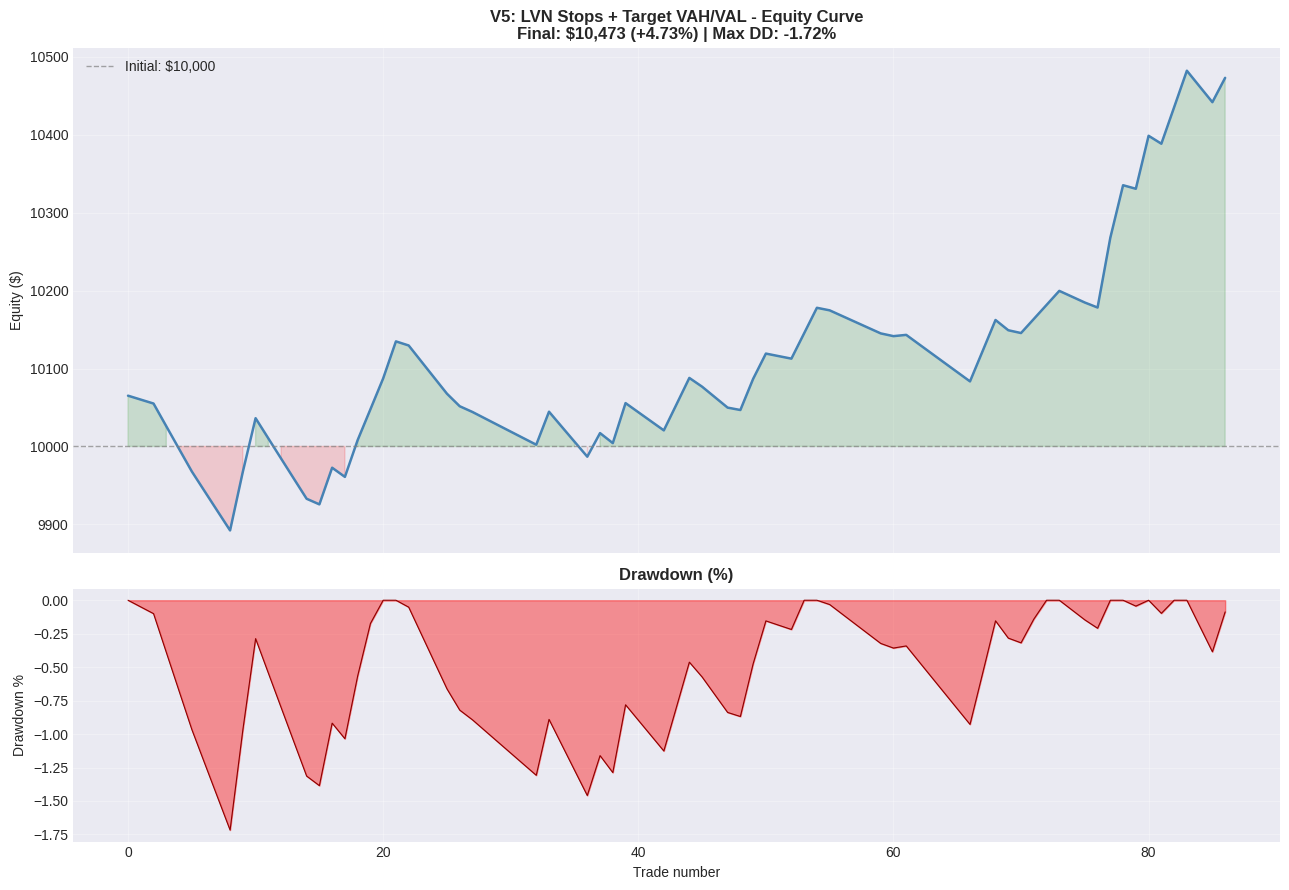

In [15]:
def plot_equity_curve(trades, strategy_name="Strategy", initial_capital=10000):
    """Plot equity curve and drawdown from a series of trades."""

    if len(trades) == 0:
        print("No trades to plot")
        return

    # Build equity curve (compounding)
    trades = trades.reset_index(drop=True).copy()
    trades['equity'] = initial_capital * (1 + trades['pnl_pct']/100).cumprod()

    # Calculate drawdown
    trades['peak'] = trades['equity'].cummax()
    trades['drawdown_pct'] = (trades['equity'] - trades['peak']) / trades['peak'] * 100

    # Key metrics
    final_equity = trades['equity'].iloc[-1]
    total_return = (final_equity/initial_capital - 1) * 100
    max_dd = trades['drawdown_pct'].min()

    # Plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9),
                                     gridspec_kw={'height_ratios': [2, 1]}, sharex=True)

    # Equity curve
    ax1.plot(trades.index, trades['equity'], linewidth=1.8, color='steelblue')
    ax1.axhline(initial_capital, color='gray', linestyle='--', linewidth=1, alpha=0.7,
                label=f'Initial: ${initial_capital:,.0f}')
    ax1.fill_between(trades.index, initial_capital, trades['equity'],
                     where=(trades['equity'] >= initial_capital), alpha=0.15, color='green')
    ax1.fill_between(trades.index, initial_capital, trades['equity'],
                     where=(trades['equity'] < initial_capital), alpha=0.15, color='red')
    ax1.set_title(f'{strategy_name} - Equity Curve\nFinal: ${final_equity:,.0f} ({total_return:+.2f}%) | Max DD: {max_dd:.2f}%',
                  fontweight='bold', fontsize=12)
    ax1.set_ylabel('Equity ($)')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)

    # Drawdown
    ax2.fill_between(trades.index, trades['drawdown_pct'], 0, color='red', alpha=0.4)
    ax2.plot(trades.index, trades['drawdown_pct'], color='darkred', linewidth=0.8)
    ax2.set_title('Drawdown (%)', fontweight='bold')
    ax2.set_ylabel('Drawdown %')
    ax2.set_xlabel('Trade number')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('equity_curve_v5.png', dpi=150, bbox_inches='tight')
    plt.show()

    return trades


# Plot equity curve for v5 (best strategy)
equity_data = plot_equity_curve(daily_trades_v5, strategy_name="V5: LVN Stops + Target VAH/VAL")

In [16]:
def quick_metrics(trades, name):
    if len(trades) == 0:
        return {'Strategy': name, 'Trades': 0, 'Win Rate %': 0,
                'Total Return %': 0, 'Avg R:R': 0}
    wins = (trades['pnl_pct'] > 0).sum()
    return {
        'Strategy': name,
        'Trades': len(trades),
        'Win Rate %': round(wins/len(trades)*100, 1),
        'Total Return %': round(trades['pnl_pct'].sum(), 2),
        'Avg R:R': round(trades['rr'].mean(), 2) if 'rr' in trades.columns else None
    }

summary = pd.DataFrame([
    quick_metrics(daily_trades, 'v1: Pure Mean Reversion'),
    quick_metrics(daily_trades_v2, 'v2: EMA filter + POC target'),
    quick_metrics(daily_trades_v3, 'v3: EMA + extended target'),
    quick_metrics(daily_trades_v5, 'v5: LVN stops + R:R filter'),
])

print("STRATEGY COMPARISON (Daily, QQQ, 60 days)")
print(summary.to_string(index=False))

STRATEGY COMPARISON (Daily, QQQ, 60 days)
                   Strategy  Trades  Win Rate %  Total Return %  Avg R:R
    v1: Pure Mean Reversion     238        58.0           -8.59      NaN
v2: EMA filter + POC target     164        64.6            0.75      NaN
  v3: EMA + extended target      99        34.3           -7.48      NaN
 v5: LVN stops + R:R filter      87        33.3            4.66     6.51


In [17]:
# Run v5 on weekly profiles
weekly_trades_v5 = backtest_lvn_stop(data, weekly_profiles, profile_type='weekly', min_rr=2.0)

print("\nWEEKLY STRATEGY v5 (EMA + LVN stops + target VAH/VAL + R:R>=2)")
print(f"Total trades: {len(weekly_trades_v5)}")
if len(weekly_trades_v5) > 0:
    wins = (weekly_trades_v5['pnl_pct'] > 0).sum()
    print(f"Win rate: {wins/len(weekly_trades_v5)*100:.1f}%")
    print(f"Total return: {weekly_trades_v5['pnl_pct'].sum():.2f}%")
    print(f"Avg return per trade: {weekly_trades_v5['pnl_pct'].mean():.3f}%")
    print(f"Avg R:R: {weekly_trades_v5['rr'].mean():.2f}")
    print(f"\nResults breakdown:")
    print(weekly_trades_v5['result'].value_counts())

# Side by side: daily vs weekly for the best strategy (v5)
print("\n" + "="*55)
print("DAILY vs WEEKLY (Strategy v5)")
print("="*55)

def full_metrics(trades, name):
    if len(trades) == 0:
        return {'Approach': name, 'Trades': 0}
    wins = trades[trades['pnl_pct'] > 0]
    losses = trades[trades['pnl_pct'] <= 0]
    # Build equity for drawdown
    eq = 10000 * (1 + trades['pnl_pct']/100).cumprod()
    peak = eq.cummax()
    max_dd = ((eq - peak)/peak*100).min()
    return {
        'Approach': name,
        'Trades': len(trades),
        'Win Rate %': round(len(wins)/len(trades)*100, 1),
        'Total Return %': round(trades['pnl_pct'].sum(), 2),
        'Avg Win %': round(wins['pnl_pct'].mean(), 3) if len(wins)>0 else 0,
        'Avg Loss %': round(losses['pnl_pct'].mean(), 3) if len(losses)>0 else 0,
        'Avg R:R': round(trades['rr'].mean(), 2) if 'rr' in trades.columns else None,
        'Max DD %': round(max_dd, 2)
    }

comparison_v5 = pd.DataFrame([
    full_metrics(daily_trades_v5, 'Daily'),
    full_metrics(weekly_trades_v5, 'Weekly')
])

print(comparison_v5.to_string(index=False))

Trades skipped due to R:R < 2.0: 0

WEEKLY STRATEGY v5 (EMA + LVN stops + target VAH/VAL + R:R>=2)
Total trades: 39
Win rate: 17.9%
Total return: 0.68%
Avg return per trade: 0.017%
Avg R:R: 12.58

Results breakdown:
result
stop         32
target        6
time_exit     1
Name: count, dtype: int64

DAILY vs WEEKLY (Strategy v5)
Approach  Trades  Win Rate %  Total Return %  Avg Win %  Avg Loss %  Avg R:R  Max DD %
   Daily      87        33.3            4.66      0.424      -0.132     6.51     -1.72
  Weekly      39        17.9            0.68      1.115      -0.223    12.58     -3.26


In [18]:
# Save all results
daily_trades_v5.to_csv('daily_trades_v5.csv', index=False)
weekly_trades_v5.to_csv('weekly_trades_v5.csv', index=False)
summary.to_csv('strategy_comparison.csv', index=False)
comparison_v5.to_csv('daily_vs_weekly.csv', index=False)

from google.colab import files
files.download('daily_trades_v5.csv')
files.download('weekly_trades_v5.csv')
files.download('strategy_comparison.csv')
files.download('daily_vs_weekly.csv')
files.download('equity_curve_v5.png')

print("All files exported.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files exported.
